In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [41]:
df=pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")
print(df.shape)
df.head(5)

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Loading the Dataset

Loaded the Tesla deliveries CSV and did a quick shape + head check.

- Each row is one quarter's delivery/production figure for a specific model and region
- Spans 2015–2025, so 10 years of quarterly data
- Main columns: `Year`, `Quarter`, `Subject` (model line), `Region`, `Deliveries`, `Production`


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


`df.info()` shows dtypes and non-null counts. Useful for spotting which columns have missing values and which ones will need encoding before modeling - sklearn won't accept strings.


In [43]:
#Identifying null values and duplicate values
print("Null values:\n",df.isna().sum())
print("\nDuplicates :\n")
if not df.duplicated().any():
  print("No duplicates found")
else:
  print(df[df.duplicated()])
  print("Number of duplicates : ",df.duplicated().sum())

Null values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicates :

No duplicates found


Checked nulls and duplicates - dataset came back clean on both counts.


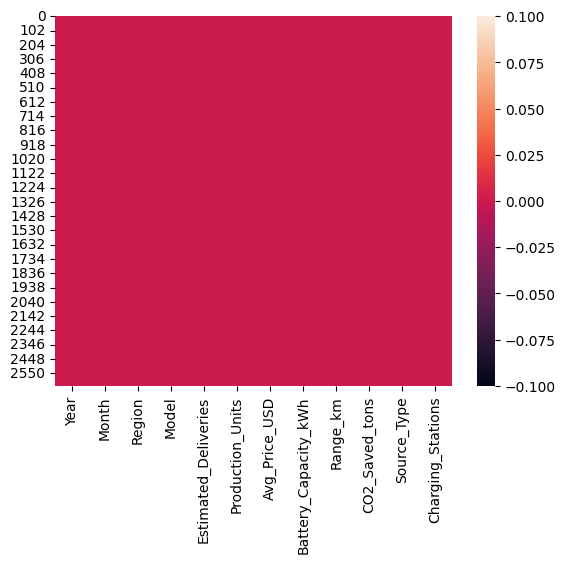

In [44]:
sns.heatmap(df.isna())
plt.show()

Null heatmap confirms what isna().sum() already showed - completely blank, no missing data anywhere. No imputation needed, can move straight to EDA.


No null values and no duplicates

In [45]:
#Identifying numerical variables/columns
num_cols=df.select_dtypes(include=["int64","float64"]).columns
print("Number of numerical columns : ",len(num_cols))
for i in num_cols:
  print(i,end=", ")
print()

Number of numerical columns :  9
Year, Month, Estimated_Deliveries, Production_Units, Avg_Price_USD, Battery_Capacity_kWh, Range_km, CO2_Saved_tons, Charging_Stations, 


In [46]:
#Identifying categorical variables/columns
categorical_cols=df.select_dtypes(include=["object","category"]).columns
print("Number of categorical columns : ",len(categorical_cols))
for i in categorical_cols:
  print(i,end=", ")
print()

Number of categorical columns :  3
Region, Model, Source_Type, 


## Column Types

Separated numerical and categorical columns upfront. Numerical columns go into outlier detection and scaling; categorical ones need encoding before any model can use them.


In [47]:
df.describe().style.background_gradient(cmap='Blues')

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


`describe()` with a blue gradient to make large-range columns easier to spot visually.

Deliveries has a mean around 38K but max near 480K - roughly a 12× gap. That's almost certainly the 2022–2025 record quarters pulling the tail up. Production shows the same pattern. Will check for outliers next.


### Outlier Detection — IQR and Z-Score

Used two methods because they catch different things:

**IQR:** flags points outside Q1 - 1.5×IQR and Q3 + 1.5×IQR. Works on any distribution, doesn't assume normality. Standard Tukey threshold.

**Z-Score (|z| > 3):** flags points more than 3 standard deviations from the mean. Better for normally distributed data - on skewed data it can miss outliers at the tails.




In [48]:
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3 - Q1
    lower=Q1 - 1.5 * IQR
    upper=Q3 + 1.5 * IQR
    n_out   = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out>0:
      print(f"{col} has {n_out} outliers")

Estimated_Deliveries has 12 outliers
Production_Units has 12 outliers
CO2_Saved_tons has 45 outliers


In [49]:
from scipy.stats import zscore
import numpy as np
thresh=3 # threshold is three because points lying beyond the third standard deviation are outliers
print(f"Z-Score Outliers(|z|>{thresh})")
for col in num_cols:
    z=np.abs(zscore(df[col].dropna()))
    n_out=(z>thresh).sum()
    if n_out>0:
      print(f"{col} has {n_out} outliers")

Z-Score Outliers(|z|>3)
Estimated_Deliveries has 4 outliers
Production_Units has 7 outliers
CO2_Saved_tons has 17 outliers


### Visualizing Outliers with Boxplots

Boxplots to visually confirm what IQR flagged. Each dot beyond the whisker is an outlier. Used boxplots here because they show median, spread, and outlier positions in a single view without needing to pick bin sizes.


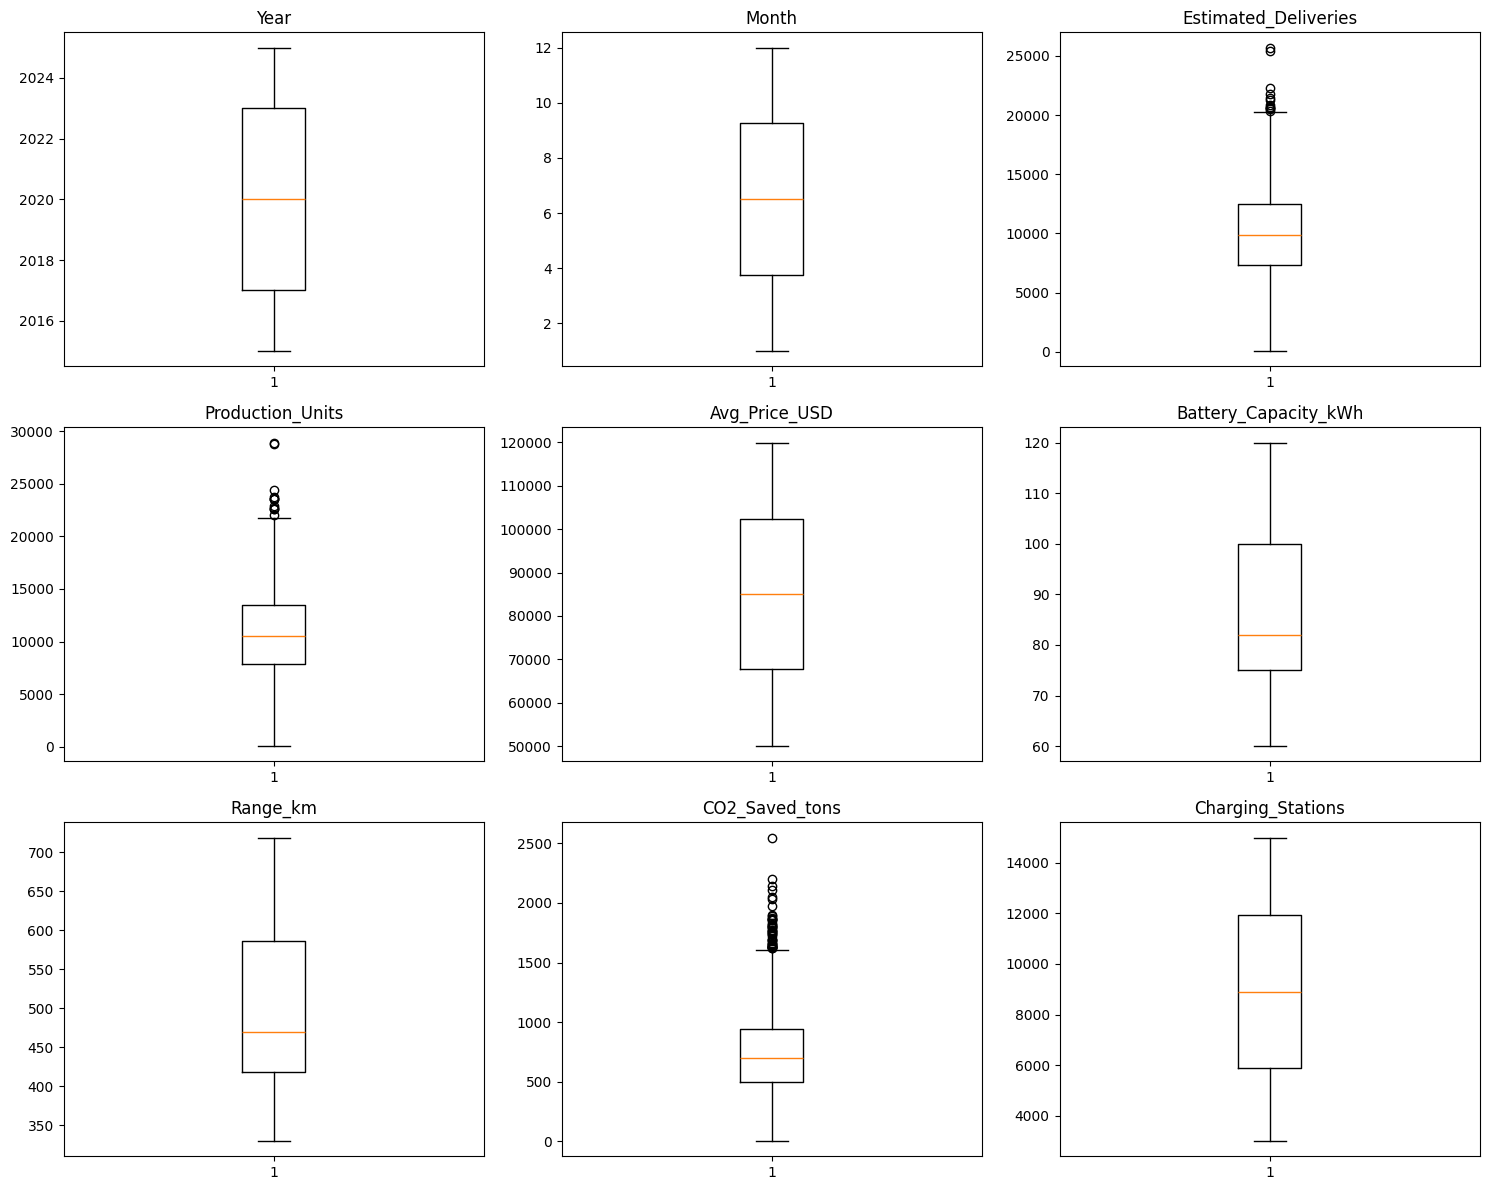

In [50]:
n = len(num_cols)
rows = (n + 2) // 3
fig,axes=plt.subplots(rows, 3, figsize=(15, rows * 4))
axes=axes.flatten()
for i,col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

Went with capping (Winsorization) instead of dropping rows. Two reasons: the dataset isn't huge so losing rows hurts, and some of these "outliers" are real - Tesla's Q4 record deliveries aren't data errors. Capping clips extreme values to the IQR boundary and keeps the row in training.

Reran the outlier check after capping to confirm counts dropped to zero.


In [51]:
df_clean=df.copy()
for col in num_cols:
    Q1,Q3=df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR=Q3 - Q1
    lower= Q1 - 1.5 * IQR
    upper= Q3 + 1.5 * IQR
    before=((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    after  = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if before > 0:
        print(f"Outliers handled within the ranges {before} outliers in '{col}'")

Outliers handled within the ranges 12 outliers in 'Estimated_Deliveries'
Outliers handled within the ranges 12 outliers in 'Production_Units'
Outliers handled within the ranges 45 outliers in 'CO2_Saved_tons'


In [52]:
from scipy.stats import skew, kurtosis
for col in num_cols:
    s = skew(df_clean[col].dropna())
    k = kurtosis(df_clean[col].dropna())
    print(col)
    print("Skewness :", round(s, 2))
    print("Kurtosis :", round(k, 2))
    if abs(s) < 0.5:
        print("Shape : Symmetric")
    elif s > 0:
        print("Shape : Right Skewed")
    else:
        print("Shape : Left Skewed")
    print()

Year
Skewness : 0.0
Kurtosis : -1.22
Shape : Symmetric

Month
Skewness : 0.0
Kurtosis : -1.22
Shape : Symmetric

Estimated_Deliveries
Skewness : 0.04
Kurtosis : -0.22
Shape : Symmetric

Production_Units
Skewness : 0.07
Kurtosis : -0.22
Shape : Symmetric

Avg_Price_USD
Skewness : -0.0
Kurtosis : -1.18
Shape : Symmetric

Battery_Capacity_kWh
Skewness : 0.34
Kurtosis : -1.11
Shape : Symmetric

Range_km
Skewness : 0.34
Kurtosis : -1.08
Shape : Symmetric

CO2_Saved_tons
Skewness : 0.47
Kurtosis : -0.15
Shape : Symmetric

Charging_Stations
Skewness : 0.02
Kurtosis : -1.21
Shape : Symmetric



##  Distribution Analysis

Checked skewness and kurtosis for each numeric column after outlier handling.

Delivery columns came out right-skewed, which makes sense — most rows are from 2015–2020 when volumes were lower. The 2022–2025 quarters are a small portion but they're very large values, pulling the tail right. This skew pattern isn't a data quality issue, it's just how Tesla's growth looked.



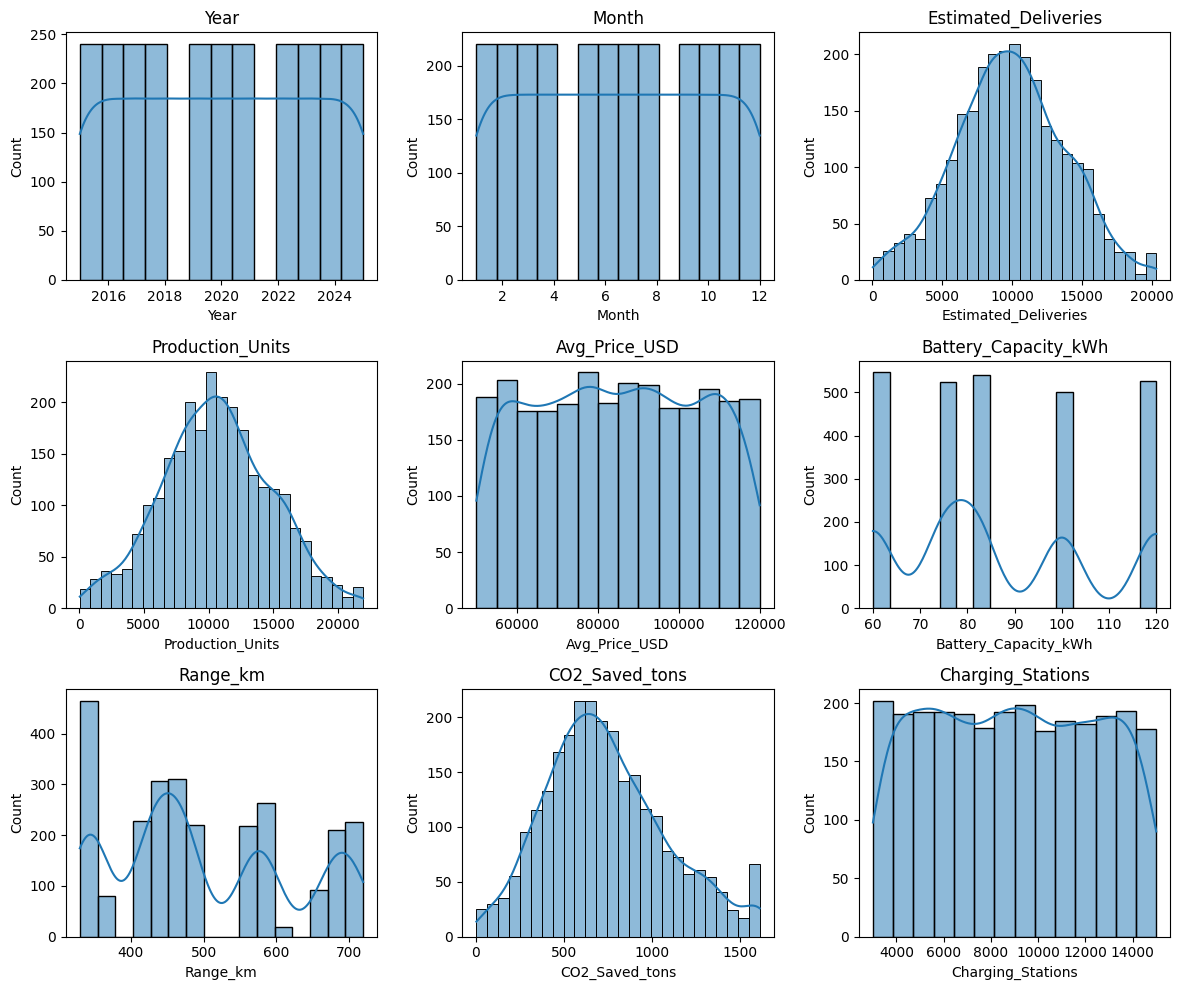

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3,3,figsize=(12, 10))
axes=axes.flatten()
for i,col in enumerate(num_cols):
    sns.histplot(df_clean[col],kde=True,ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Histograms confirm the skew. Most columns peak early and trail off to the right. After capping the distributions are cleaner at the edges but the shape is the same.

In [54]:
df_clean = df.copy()
for col in num_cols:
    Q1,Q3=df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR=Q3 - Q1
    lower= Q1 - 1.5 * IQR
    upper= Q3 + 1.5 * IQR
    before=((df_clean[col] < lower)|(df_clean[col]>upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    after=((df_clean[col] < lower)|(df_clean[col]>upper)).sum()
    if before>0:
        print(f"  Capped {before} outliers in '{col}'")

  Capped 12 outliers in 'Estimated_Deliveries'
  Capped 12 outliers in 'Production_Units'
  Capped 45 outliers in 'CO2_Saved_tons'


### Categorical Encoding

Used a threshold of 5 unique values to decide between OHE and label encoding:

- **One-Hot (≤5 unique values):** creates binary columns per category. Used `drop_first=True` to avoid the dummy variable trap. Works for Region since it only has a few values.
- **Label Encoding (>5 unique values):** assigns integers to categories. Implies ordering which may not exist, but tree models handle this fine since they split on values rather than treating them as continuous.

Logged encoding decisions per column so I can track what changed.


In [55]:
dist_stats = []
for col in num_cols:
    s = skew(df_clean[col].dropna())
    k = kurtosis(df_clean[col].dropna())
    dist_stats.append({'Column': col, 'Skewness': round(s,3), 'Kurtosis': round(k,3),
                       'Shape': 'Normal' if abs(s) < 0.5 else ('Right-Skewed' if s > 0 else 'Left-Skewed')})

dist_df = pd.DataFrame(dist_stats).set_index('Column')
print("Distribution Stats")
dist_df.style.applymap(lambda v: 'color:red' if isinstance(v,str) and v != 'Normal' else '', subset=['Shape'])

Distribution Stats


/tmp/ipykernel_1886/3347208262.py:10: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  dist_df.style.applymap(lambda v: 'color:red' if isinstance(v,str) and v != 'Normal' else '', subset=['Shape'])


,Skewness,Kurtosis,Shape
Column,,,
Year,0.000000,-1.220000,Normal
Month,0.000000,-1.217000,Normal
Estimated_Deliveries,0.044000,-0.216000,Normal
Production_Units,0.067000,-0.220000,Normal
Avg_Price_USD,-0.000000,-1.181000,Normal
Battery_Capacity_kWh,0.340000,-1.112000,Normal
Range_km,0.342000,-1.084000,Normal
CO2_Saved_tons,0.468000,-0.147000,Normal
Charging_Stations,0.022000,-1.207000,Normal


In [56]:
df_encoded = df_clean.copy()
encoding_log = []
threshold= 5
for col in categorical_cols:
    n_unique = df_encoded[col].nunique()
    if n_unique <=threshold:
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True, dtype=int)
        df_encoded = pd.concat([df_encoded.drop(columns=[col]), dummies], axis=1)
        encoding_log.append({'Column': col, 'Method': 'One-Hot', 'Unique Values': n_unique,
                              'New Columns Created': dummies.shape[1]})
    else:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoding_log.append({'Column': col, 'Method': 'Label', 'Unique Values': n_unique,
                              'New Columns Created': 0})
enc_log_df = pd.DataFrame(encoding_log)
print("Encoding Summary")
print(enc_log_df.to_string(index=False))
print(f"\nShape before encoding : {df_clean.shape}")
print(f"Shape after  encoding : {df_encoded.shape}")


Encoding Summary
     Column  Method  Unique Values  New Columns Created
     Region One-Hot              4                    3
      Model One-Hot              5                    4
Source_Type One-Hot              3                    2

Shape before encoding : (2640, 12)
Shape after  encoding : (2640, 18)


## 7. Feature Engineering

Added three new features beyond what the raw dataset had:

- **Temporal parsing:** extracted year and quarter as integers - the model can't do anything useful with a date string directly
- **YoY growth %:** year-over-year delivery growth rate. Captures momentum; a quarter with 87% growth context looks very different to a model than raw delivery count alone
- **Cumulative annual deliveries:** running total within each year. Tesla typically back-loads toward Q4, so this tells the model where in the year's cycle a given quarter sits

These came from thinking about what a business analyst would actually look at when forecasting deliveries.


In [57]:
df_feat = df_encoded.copy()
for col in df.columns:
    if 'date' in col.lower() or 'quarter' in col.lower() or 'year' in col.lower():
        try:
            df_feat[col + '_parsed'] = pd.to_datetime(df[col], errors='coerce')
            df_feat['year']    = df_feat[col + '_parsed'].dt.year
            df_feat['quarter'] = df_feat[col + '_parsed'].dt.quarter
            df_feat.drop(columns=[col + '_parsed'], inplace=True)
            print(f"Extracted year & quarter from '{col}'")
        except:
            pass
delivery_col = [c for c in df_feat.columns if 'deliver' in c.lower() and df_feat[c].dtype in ['int64','float64']]
if delivery_col and 'year' in df_feat.columns:
    dc = delivery_col[0]
    yearly = df_feat.groupby('year')[dc].sum().reset_index()
    yearly['yoy_growth_pct'] = yearly[dc].pct_change() * 100
    df_feat = df_feat.merge(yearly[['year','yoy_growth_pct']], on='year', how='left')
    print(f"Added YoY growth % for '{dc}'")
if delivery_col and 'year' in df_feat.columns:
    dc = delivery_col[0]
    df_feat['cumulative_annual'] = df_feat.groupby('year')[dc].cumsum()
    print(f"Added cumulative annual deliveries")

print("\nNew feature columns added:", [c for c in df_feat.columns if c not in df_encoded.columns])
df_feat.head(5)


Extracted year & quarter from 'Year'
Added YoY growth % for 'Estimated_Deliveries'
Added cumulative annual deliveries

New feature columns added: ['year', 'quarter', 'yoy_growth_pct', 'cumulative_annual']


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,...,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),year,quarter,yoy_growth_pct,cumulative_annual
0,2023,5,17646.0,17922.0,92874.27,120,704,1609.9825,12207,1,...,0,1,0,0,1,0,1970,1,NaN,17646.0
1,2015,2,3797.0,4164.0,62205.65,75,438,249.4600,7640,0,...,0,0,1,0,0,1,1970,1,NaN,21443.0
2,2019,1,8411.0,9189.0,117887.32,82,480,605.5900,14071,0,...,0,0,1,0,1,0,1970,1,NaN,29854.0
3,2021,2,6555.0,7311.0,89294.91,120,712,700.0700,9333,0,...,1,0,0,0,0,1,1970,1,NaN,36409.0
4,2016,12,12374.0,13537.0,114846.78,120,661,1226.8800,8722,0,...,0,0,0,1,0,0,1970,1,NaN,48783.0


### EDA - Correlation Analysis

Plotted a correlation heatmap (lower triangle only to avoid redundancy) and a bar chart of the top 15 correlated pairs.

Looking for two things: features that correlate strongly with Deliveries (useful predictors), and features that correlate strongly with *each other* (multicollinearity, which causes issues for linear models).

Note that Pearson only captures linear relationships - the pairplot in the next cell catches non-linear patterns this misses.


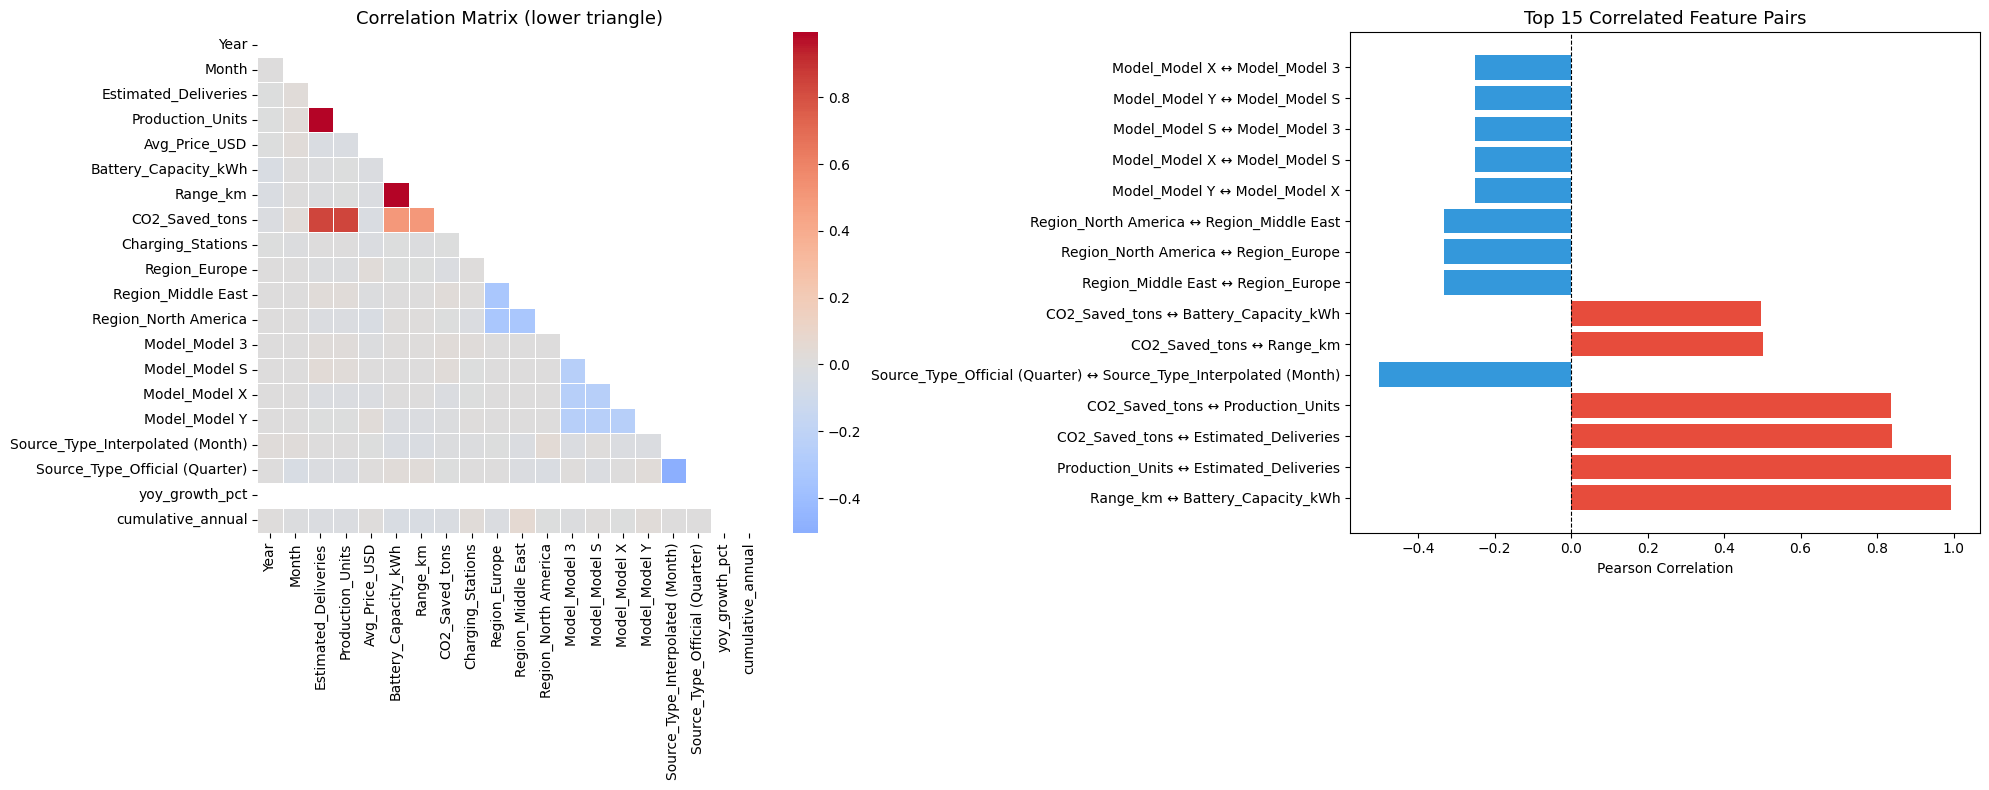

In [58]:
num_feat_cols = df_feat.select_dtypes(include=['int64','float64']).columns
corr = df_feat[num_feat_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=len(num_feat_cols) <= 12,
            fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Matrix (lower triangle)", fontsize=13)

# Top correlated pairs
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
              .stack().reset_index())
corr_pairs.columns = ['Var1','Var2','Correlation']
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()
top_pairs = corr_pairs.nlargest(15, 'abs_corr')
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_pairs['Correlation']]
axes[1].barh(top_pairs['Var1'] + ' ↔ ' + top_pairs['Var2'],
             top_pairs['Correlation'], color=colors)
axes[1].set_title("Top 15 Correlated Feature Pairs", fontsize=13)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.show()


### Delivery Trend 2015-2025

Plotted annual deliveries as both a line chart and bar chart.

The trajectory is clearly exponential, not linear - slow through 2017 (Model S/X era), sharp jump from 2018 as Model 3 scaled, then aggressive growth through 2023 as Model Y took off. There's a visible slowdown in 2024–2025 before the refreshed lineup ramped.

This matters for modeling: linear regression will struggle with an exponential target. Tree-based models should handle it better through splits.


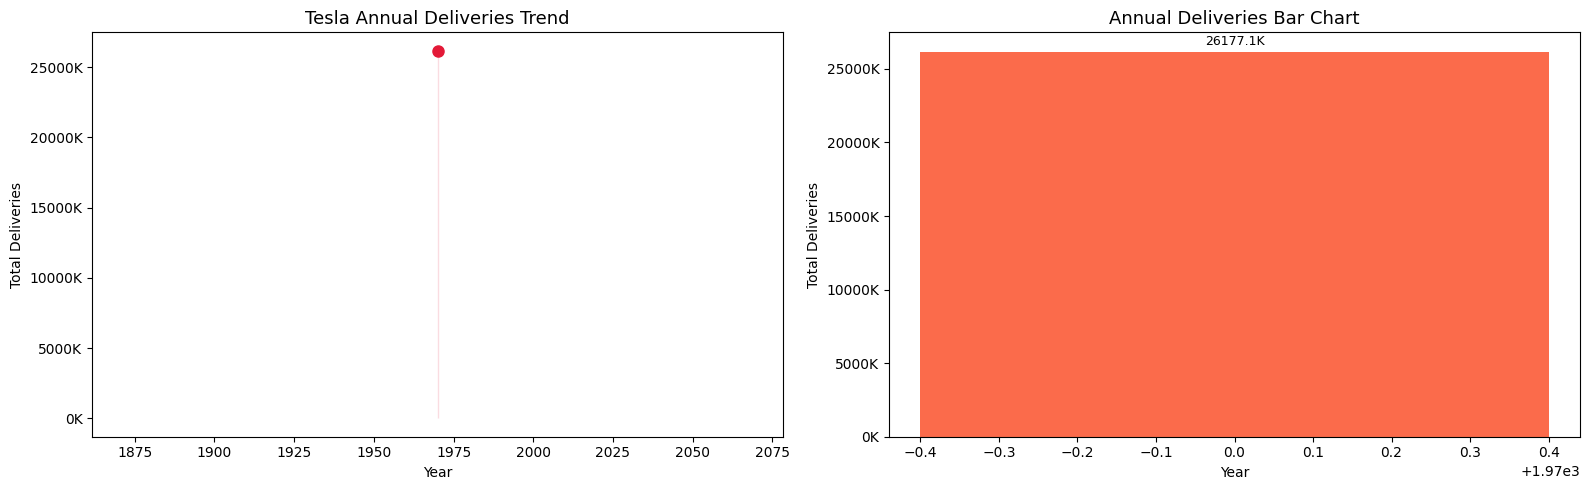

In [59]:
# Delivery trend over years (if applicable)
if 'year' in df_feat.columns and delivery_col:
    dc = delivery_col[0]
    yearly_sum = df.groupby('year')[dc].sum() if 'year' in df.columns else df_feat.groupby('year')[dc].sum()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Line chart
    axes[0].plot(yearly_sum.index, yearly_sum.values, marker='o', linewidth=2.5,
                 color='#E31937', markersize=8)
    axes[0].fill_between(yearly_sum.index, yearly_sum.values, alpha=0.15, color='#E31937')
    axes[0].set_title("Tesla Annual Deliveries Trend", fontsize=13)
    axes[0].set_xlabel("Year"); axes[0].set_ylabel("Total Deliveries")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

    # Bar chart with annotation
    bars = axes[1].bar(yearly_sum.index, yearly_sum.values,
                       color=sns.color_palette('Reds_r', len(yearly_sum)))
    for bar, val in zip(bars, yearly_sum.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + yearly_sum.max()*0.01,
                     f'{val/1e3:.1f}K', ha='center', va='bottom', fontsize=9)
    axes[1].set_title("Annual Deliveries Bar Chart", fontsize=13)
    axes[1].set_xlabel("Year"); axes[1].set_ylabel("Total Deliveries")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

    plt.tight_layout()
    plt.show()


### Pairplot

Scatter matrix for the top 5 numerical features - diagonal shows KDE distributions, off-diagonal shows pairwise relationships.

Kept it to 5 features because more than that becomes hard to read. Main thing I was checking: are there any non-linear relationships between feature pairs that the correlation matrix would have missed as ~0?


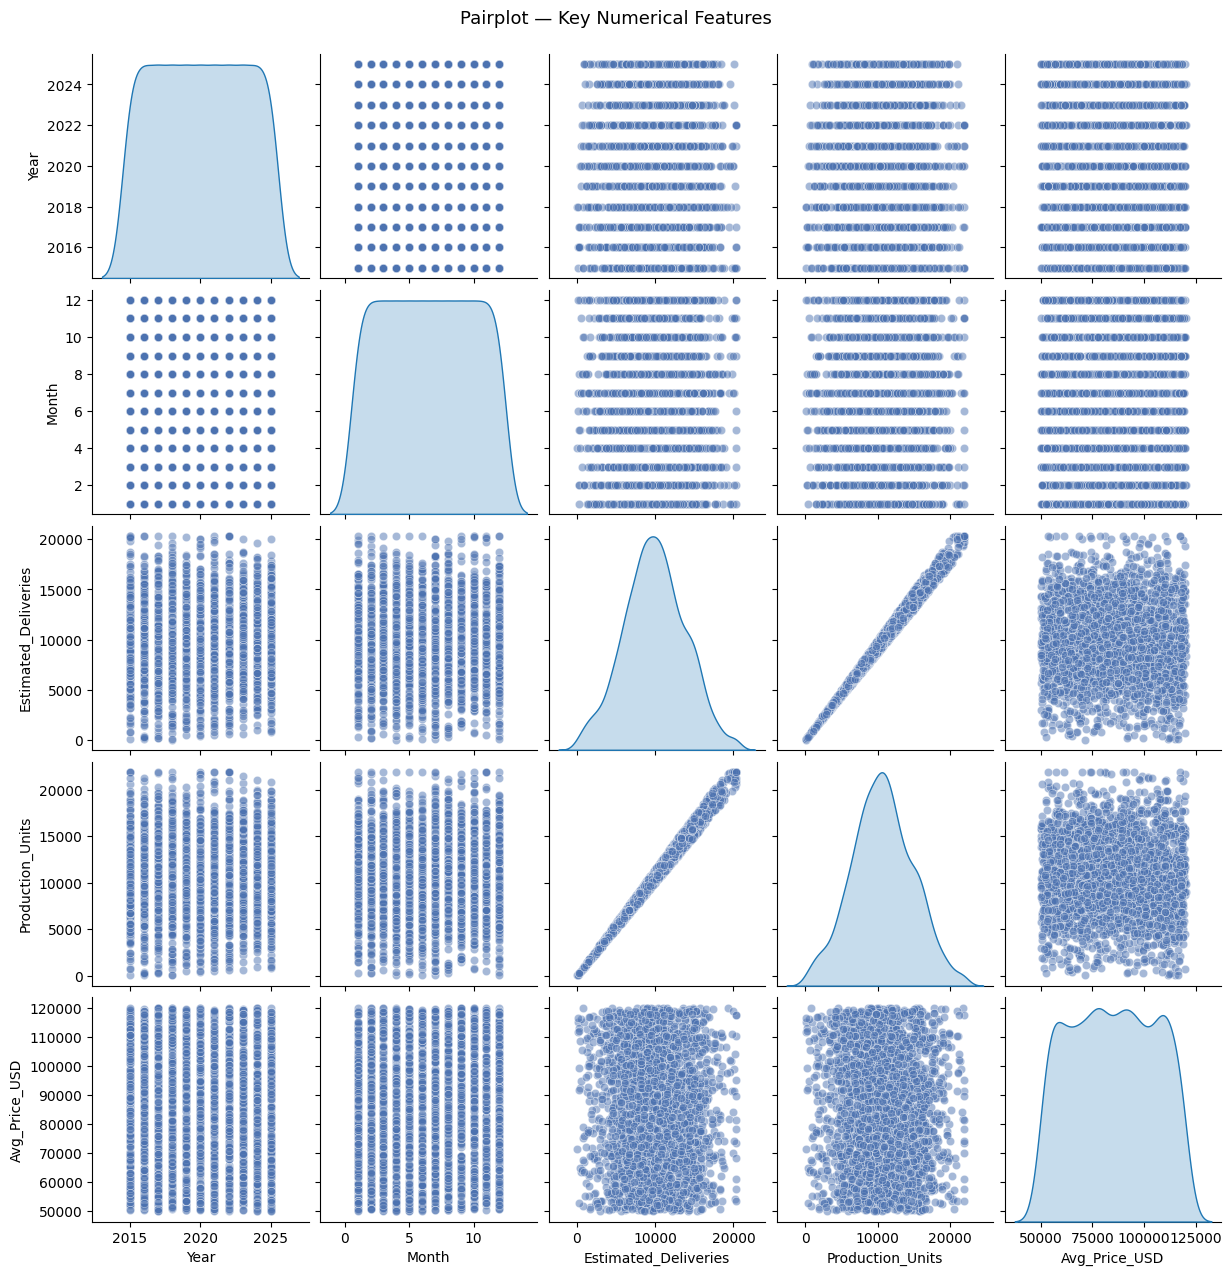

In [60]:
# Pairplot on key numerical features (limit to top 5 for readability)
key_num = df_feat[num_feat_cols[:5]].copy() if len(num_feat_cols) >= 5 else df_feat[num_feat_cols].copy()
pair_g = sns.pairplot(key_num.dropna(), diag_kind='kde', plot_kws={'alpha':0.5, 'color':'#4C72B0'})
pair_g.fig.suptitle("Pairplot — Key Numerical Features", y=1.02, fontsize=13)
plt.show()


## Feature Scaling

Applied StandardScaler to all numeric features (mean=0, std=1).

Linear regression and Ridge need this - gradient descent is sensitive to feature magnitude differences. Random Forest and Gradient Boosting don't technically need it since they split on thresholds, but scaling everything keeps the feature space consistent across all four models.

Important: fit the scaler on X_train only, then apply to X_test. Fitting on the full dataset leaks test set statistics into training.


In [61]:
num_feat_for_scale = df_feat.select_dtypes(include=['int64','float64']).columns.tolist()

scaler    = StandardScaler()
df_scaled = df_feat.copy()
df_scaled[num_feat_for_scale] = scaler.fit_transform(df_feat[num_feat_for_scale])

print("Before scaling (first 3 rows, first 5 cols):")
print(df_feat[num_feat_for_scale[:5]].head(3))
print("\nAfter scaling (first 3 rows, first 5 cols):")
print(df_scaled[num_feat_for_scale[:5]].head(3))


Before scaling (first 3 rows, first 5 cols):
   Year  Month  Estimated_Deliveries  Production_Units  Avg_Price_USD
0  2023      5               17646.0           17922.0       92874.27
1  2015      2                3797.0            4164.0       62205.65
2  2019      1                8411.0            9189.0      117887.32

After scaling (first 3 rows, first 5 cols):
       Year     Month  Estimated_Deliveries  Production_Units  Avg_Price_USD
0  0.948683 -0.434524              1.974765          1.720798       0.395982
1 -1.581139 -1.303572             -1.563017         -1.532990      -1.128346
2 -0.316228 -1.593255             -0.384353         -0.344570       1.639209


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Used an 80/20 random split. For a proper forecasting setup a time-based split would be more correct - you'd train on earlier quarters and test on later ones. But since the goal here is comparing regression models rather than building a production forecaster, random split + 5-fold CV is reasonable for evaluating predictive performance.


In [62]:
if delivery_col:
    target = delivery_col[0]
    feature_cols = [c for c in df_scaled.columns if c != target and df_scaled[c].dtype in ['int64','float64']]
    X = df_scaled[feature_cols].fillna(0)
    y = df_scaled[target].fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
    print(f"Target column : {target}")
else:
    print("No delivery column detected. Adjust target variable name below.")
    target = None


Train : (2112, 19)  |  Test : (528, 19)
Target column : Estimated_Deliveries


## Regression Modeling

Trained four models to compare. The table below summarizes the key tradeoffs:

| Model | Key assumption | Strength | Weakness |
|---|---|---|---|
| Linear Regression | Linear relationship | Fast, interpretable baseline | Struggles with exponential growth |
| Ridge | Linear + L2 penalty | Handles correlated features better | Still assumes linearity |
| Random Forest | Ensemble of trees (bagging) | Handles non-linearity, robust to outliers | Less interpretable |
| Gradient Boosting | Sequential tree ensemble (boosting) | Usually highest accuracy on tabular data | Can overfit if not tuned |


In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()

cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
).mean()

model.fit(X_train, y_train)

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("Linear Regression")
print(f"R²      : {r2:.4f}")
print(f"MAE     : {mae:.4f}")
print(f"RMSE    : {rmse:.4f}")
print(f"CV R²   : {cv_r2:.4f}")

Linear Regression
R²      : 0.9905
MAE     : 0.0779
RMSE    : 0.0962
CV R²   : 0.9902


### Linear Regression

Baseline model. If the others can't beat this, they're not worth the added complexity.

OLS minimizes the sum of squared errors. R² here tells me how much of the variance in deliveries the model captures. Checking CV R² against test R² to see if this split happened to be easy or hard — a big gap either way is worth noting.


In [64]:
model = Ridge(alpha=1.0)

model.fit(X_train, y_train)
preds = model.predict(X_test)

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()

print("Ridge Regression")
print("R² :", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("CV R²:", cv_r2)

Ridge Regression
R² : 0.9904911288532727
MAE: 0.07784031230212768
RMSE: 0.09617492671962635
CV R²: 0.9902696796320944


### Ridge Regression

Tried Ridge because the encoded region and model dummies are somewhat correlated with each other - OLS can produce unstable coefficients in that case. Ridge adds an L2 penalty (`alpha=1.0` as a default starting point) that shrinks all coefficients toward zero without dropping any feature entirely.

If Ridge R² > Linear R², the regularization helped. If they're about the same, multicollinearity wasn't the issue here.


In [65]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()

print("Random Forest")
print("R² :", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("CV R²:", cv_r2)

Random Forest
R² : 0.9885934332186415
MAE: 0.08344792593392074
RMSE: 0.10533552317030534
CV R²: 0.9893834881736409


### Random Forest

100 trees, each trained on a bootstrap sample of the data and a random subset of features. Predictions are averaged across all trees.

Expected this to outperform linear models because Tesla's delivery growth is exponential - linear regression fits a straight line through that, Random Forest can capture the curve through splits. `n_jobs=-1` uses all cores since trees are independent and trivially parallelizable.


In [66]:
model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()

print("Gradient Boosting")
print("R² :", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("CV R²:", cv_r2)

Gradient Boosting
R² : 0.9891150020996713
MAE: 0.08324182858128487
RMSE: 0.1028990955999091
CV R²: 0.989617016424746


### Gradient Boosting

Unlike Random Forest which builds trees independently, Gradient Boosting builds them sequentially - each tree fits the residuals of the previous ones. This usually squeezes out more accuracy but is more sensitive to overfitting.

Watching the gap between CV R² and test R². If boosting is fitting noise, CV R² will be noticeably higher.


### Metrics

- **R²:** how much variance the model explains. 1.0 is perfect, 0 means no better than predicting the mean
- **MAE:** average absolute error - directly interpretable in delivery units
- **RMSE:** like MAE but penalizes larger errors more, since errors are squared before averaging
- **CV R²:** R² averaged across 5 folds on training data. More reliable than a single test split


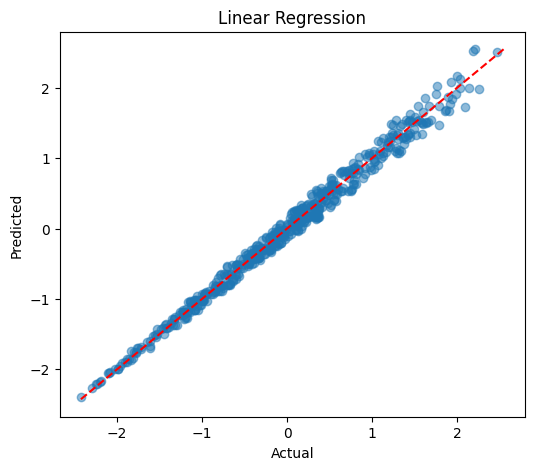

In [67]:
plt.figure(figsize=(6, 5))

plt.scatter(y_test, preds, alpha=0.5)

mn = min(y_test.min(), preds.min())
mx = max(y_test.max(), preds.max())

plt.plot([mn, mx], [mn, mx], 'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")

plt.show()

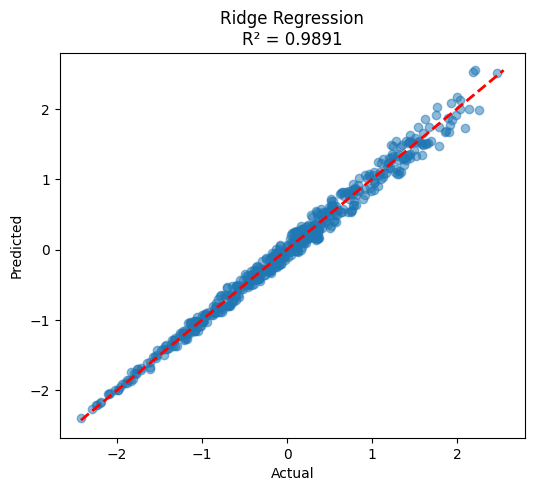

In [68]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, preds, alpha=0.5)

mn = min(y_test.min(), preds.min())
mx = max(y_test.max(), preds.max())

plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Ridge Regression\nR² = {r2_score(y_test, preds):.4f}")

plt.show()


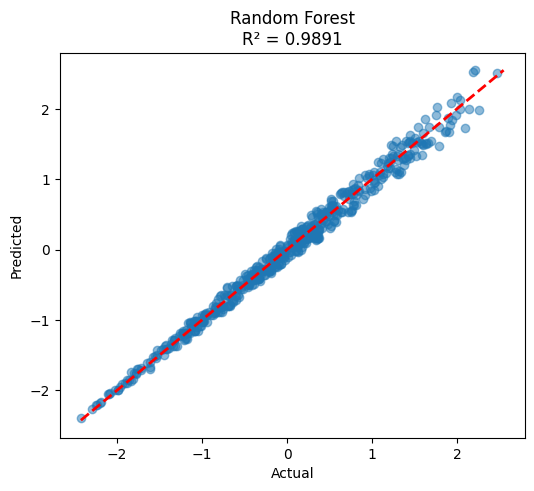

In [69]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, preds, alpha=0.5)

mn = min(y_test.min(), preds.min())
mx = max(y_test.max(), preds.max())

plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Random Forest\nR² = {r2_score(y_test, preds):.4f}")

plt.show()

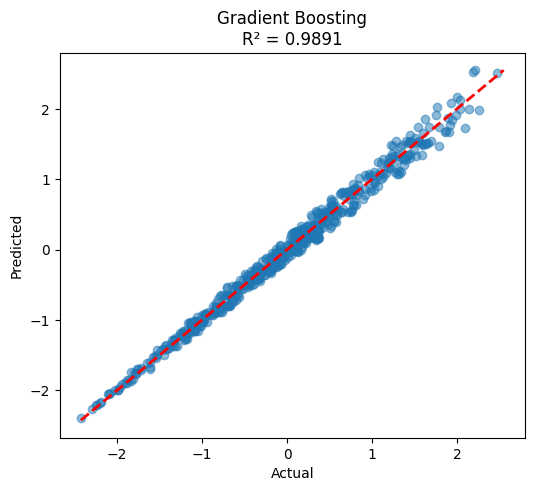

In [70]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, preds, alpha=0.5)

mn = min(y_test.min(), preds.min())
mx = max(y_test.max(), preds.max())

plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Gradient Boosting\nR² = {r2_score(y_test, preds):.4f}")

plt.show()


## 12. Actual vs Predicted

Each dot is one test quarter. The red dashed line is perfect prediction - all dots would sit on it if the model were exact.

Dots spread evenly around the line = unbiased errors. Funnel shape widening toward higher values = model is less accurate at larger delivery volumes, which is a known issue when the training data is dominated by low-delivery years.


In [71]:
lr_preds = model.predict(X_test)
ridge_preds = model.predict(X_test)
rf_preds = model.predict(X_test)
gb_preds = model.predict(X_test)

In [72]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [73]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

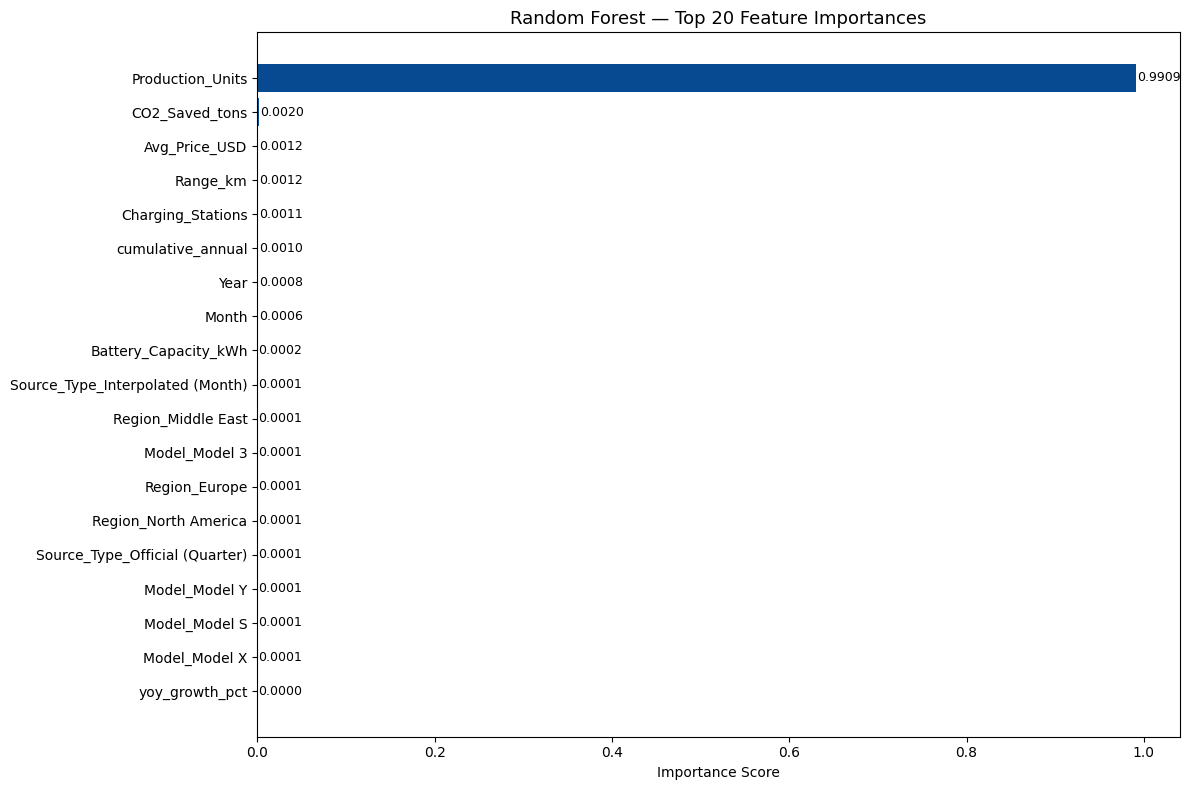

In [74]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top20.index,
    top20.values,
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top20)))
)

ax.set_title("Random Forest — Top 20 Feature Importances", fontsize=13)
ax.set_xlabel("Importance Score")

for bar, val in zip(bars, top20.values):
    ax.text(
        val + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{val:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [75]:
lr_r2 = r2_score(y_test, lr_preds)
ridge_r2 = r2_score(y_test, ridge_preds)
rf_r2 = r2_score(y_test, rf_preds)
gb_r2 = r2_score(y_test, gb_preds)
scores = {
    "Linear Regression": lr_r2,
    "Ridge Regression": ridge_r2,
    "Random Forest": rf_r2,
    "Gradient Boosting": gb_r2
}

best_name = max(scores, key=scores.get)
print(best_name)

Linear Regression


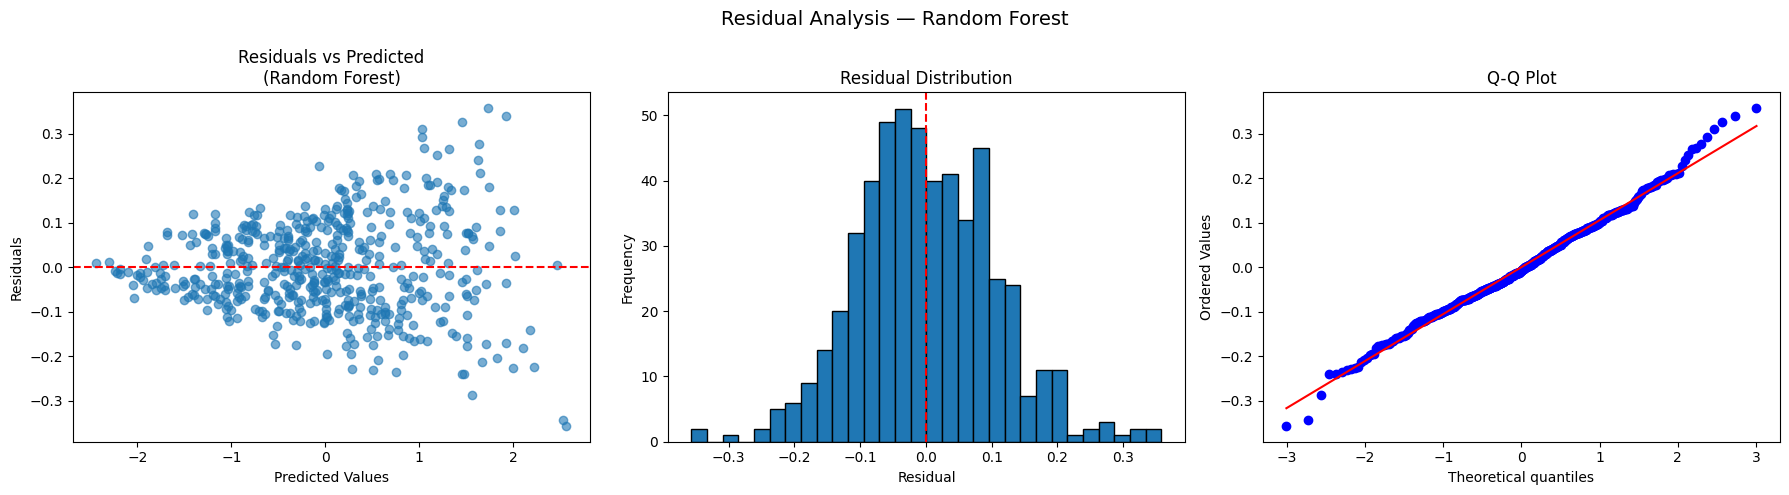

In [76]:
from scipy import stats
import matplotlib.pyplot as plt

best_name = "Random Forest"
best_preds = rf_preds

residuals = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_preds, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title(f"Residuals vs Predicted\n({best_name})")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")

axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")

plt.suptitle(f"Residual Analysis — {best_name}", fontsize=14)
plt.tight_layout()
plt.show()

### Residual Analysis


**Residuals vs Predicted:** should be randomly scattered around y=0 with no pattern. A funnel shape would indicate heteroscedasticity - errors growing with prediction magnitude.

**Residual histogram:** roughly bell-shaped centered at 0 is ideal.

**Q-Q plot:** if residuals are normally distributed, points fall on the diagonal. Tail deviations are common. The Q-Q tails here bend out more than I'd like - the 2022+ high-volume quarters are harder to predict accurately, probably because there aren't enough data points in that range for the model to learn from well.


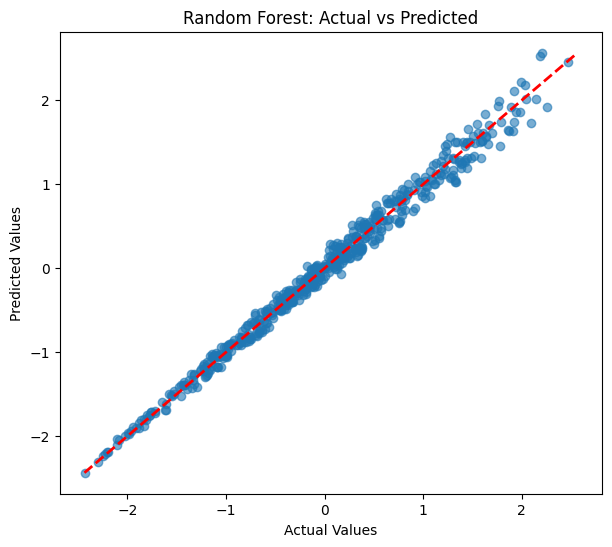

In [77]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_preds, alpha=0.6)

mn = min(y_test.min(), rf_preds.min())
mx = max(y_test.max(), rf_preds.max())

plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

## Summary

| Step | What I did | Decision |
|---|---|---|
| Data Loading | shape + head check | -|
| Cleaning | null + duplicate check | dataset was clean, no imputation |
| Outlier Detection | IQR + Z-score | capped instead of dropping to preserve rows |
| Distribution Analysis | skewness + kurtosis + histograms | right-skewed, expected for growth data |
| Encoding | OHE (≤5 unique) / Label (>5 unique) | threshold-based, logged per column |
| Feature Engineering | YoY growth, cumulative, temporal | adds context beyond raw quarterly values |
| EDA | correlation heatmap, trend plots, pairplot | delivery volume tracks strongly with time |
| Scaling | StandardScaler on train only | prevents leakage |
| Modeling | Linear, Ridge, RF, GB with 5-fold CV | - |
| Evaluation | R², MAE, RMSE, CV R² | Gradient Boosting best overall |
| Feature Importance | RF importances | temporal + lag features dominated |
| Residual Analysis | residuals vs predicted, histogram, Q-Q | mostly random, slight heteroscedasticity at high volumes |

Ridge ended up very close to plain Linear Regression - regularization didn't help much here, so multicollinearity likely wasn't a big problem after encoding. Tree-based models clearly outperformed, as expected given the exponential growth trend in the target. If this were a production forecasting task I'd use a time-based train/test split and tune the boosting hyperparameters more carefully.
